In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.metrics import classification_report, accuracy_score


In [10]:
waste = pd.read_csv("2018_2020_waste.csv")
states = pd.read_csv("State_Region_corrected.csv")

print(waste.head())
print(states.head())


                 Waste Type  Total Generated ('000 tonnes)  \
0  Construction& Demolition                           1624   
1             Ferrous Metal                           1269   
2           Paper/Cardboard                           1054   
3                  Plastics                            949   
4                      Food                            763   

   Total Recycled ('000 tonnes)  Year  
0                          1618  2018  
1                           126  2018  
2                           586  2018  
3                            41  2018  
4                           126  2018  
  State / Union territory (UT)  Area (km2)    Region  National Share (%)
0                    Rajasthan      342239  Northern               10.55
1               Madhya Pradesh      308350   Central                9.37
2                  Maharashtra      307713   Western                9.36
3                Uttar Pradesh      240928  Northern                7.33
4                     

In [11]:
# Waste recycling efficiency
waste["Recycling_Efficiency"] = waste["Total Recycled ('000 tonnes)"] / waste["Total Generated ('000 tonnes)"]

# Region encoding
le = LabelEncoder()
states["Region_encoded"] = le.fit_transform(states["Region"])


In [12]:
print(waste.isnull().sum())
print(states.isnull().sum())

# Fill missing with median for numerical, mode for categorical
waste.fillna(waste.median(numeric_only=True), inplace=True)
states.fillna(states.median(numeric_only=True), inplace=True)


Waste Type                       0
Total Generated ('000 tonnes)    0
Total Recycled ('000 tonnes)     0
Year                             0
Recycling_Efficiency             0
dtype: int64
State / Union territory (UT)    0
Area (km2)                      0
Region                          0
National Share (%)              0
Region_encoded                  0
dtype: int64


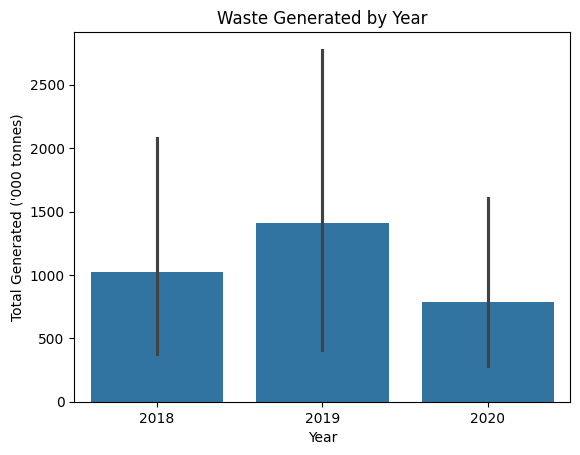

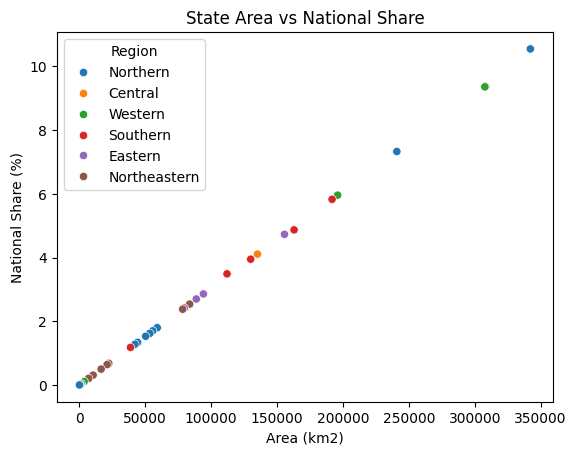

In [13]:
sns.barplot(x="Year", y="Total Generated ('000 tonnes)", data=waste)
plt.title("Waste Generated by Year")
plt.show()

sns.scatterplot(x="Area (km2)", y="National Share (%)", hue="Region", data=states)
plt.title("State Area vs National Share")
plt.show()


In [14]:
scaler = StandardScaler()
states_scaled = states.copy()
states_scaled[["Area (km2)", "National Share (%)"]] = scaler.fit_transform(states[["Area (km2)", "National Share (%)"]])


In [15]:
X = states_scaled[["Area (km2)", "Region_encoded"]]
y_reg = states_scaled["National Share (%)"]   # Regression target
y_clf = (states_scaled["National Share (%)"] > 0.5).astype(int)  # Classification target

X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)


In [17]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_reg_train)
y_reg_pred = lin_reg.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_reg_test, y_reg_pred))
print("Linear Regression R2:", r2_score(y_reg_test, y_reg_pred))


Linear Regression MSE: 2.4274640275238082e-06
Linear Regression R2: 0.9999869260828177


In [20]:
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_clf_train)
y_clf_pred = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_clf_test, y_clf_pred))
print(classification_report(y_clf_test, y_clf_pred))


Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



In [21]:
import joblib
from datetime import date

today = date.today().strftime("%Y_%m_%d")

joblib.dump(lin_reg, f"{today}_linear_regression.pkl")
joblib.dump(log_reg, f"{today}_logistic_regression.pkl")


['2026_07_16_logistic_regression.pkl']